In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

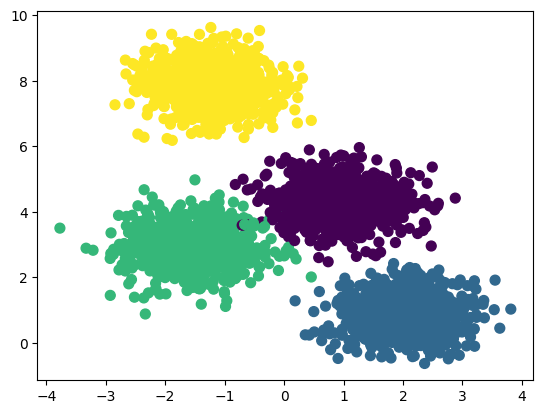

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# ISOLATION FOREST — SCRATCH IMPLEMENTATION EVALUATION (DUMMY DATA)
#
# make_blobs gives cluster labels (0-3), NOT anomaly labels, so we:
#   1. Treat all blob points as "normal"  (label = 0)
#   2. Inject random outliers far outside the cluster region (label = 1)
#   3. Split into train/test and evaluate the scratch IsolationForest
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=3000, centers=4, cluster_std=0.60, random_state=0)
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], s=50,c=y, cmap='viridis')

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   

In [ ]:

import sys, os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

_models_dir = os.path.dirname(os.path.abspath('dummy_data.ipynb'))
if _models_dir not in sys.path:
    sys.path.insert(0, _models_dir)

from if_scratch import (
    IsolationForestScratch,
    confusion_matrix_scratch,
    accuracy_score_scratch,
    classification_report_scratch,
)

print("✓ if_scratch.py imported successfully\n")

# ── BUILD ANOMALY-LABELLED DATASET ────────────────────────────────────────────
rng = np.random.RandomState(42)

# All blob points are normal (0)
X_normal = X                                         # shape (3000, 2)
y_normal = np.zeros(len(X_normal), dtype=int)

# Inject 150 outliers scattered far outside the cluster region
n_outliers = 150
X_outliers = rng.uniform(low=-10, high=10, size=(n_outliers, X.shape[1]))
y_outliers = np.ones(n_outliers, dtype=int)

X_all = np.vstack([X_normal, X_outliers])
y_all = np.concatenate([y_normal, y_outliers])

contamination = n_outliers / len(X_all)             # ≈ 0.048

# Stratified split so both splits see the same anomaly ratio
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"Dataset  : {len(X_all):,} samples  ({n_outliers} outliers, contamination={contamination:.3f})")
print(f"Train    : {len(X_tr):,}   |   Test: {len(X_te):,}")
print()

# ── FIT ───────────────────────────────────────────────────────────────────────
print("=" * 60)
print("  ISOLATION FOREST — FROM SCRATCH")
print(f"  n_estimators=300, max_samples=256,")
print(f"  max_features=0.8, contamination={contamination:.3f}")
print("=" * 60)

scratch_model = IsolationForestScratch(
    n_estimators  = 300,
    max_samples   = 256,
    max_features  = 0.8,
    contamination = contamination,
    random_state  = 42,
)

print("\nFitting on X_tr … (pure Python — may take ~60-90s for 300 trees)")
scratch_model.fit(X_tr)
print("✓ Fit complete\n")

# ── PREDICT ───────────────────────────────────────────────────────────────────
# scratch predict() returns sklearn convention:  +1 = normal, -1 = anomaly
raw_preds     = scratch_model.predict(X_te)
y_scratch_pred = [1 if p == -1 else 0 for p in raw_preds]

# ── CONFUSION MATRIX ──────────────────────────────────────────────────────────
cm = confusion_matrix_scratch(list(y_te), y_scratch_pred)
TN, FP = cm[0]
FN, TP = cm[1]

print("─" * 50)
print("  CONFUSION MATRIX  [[TN, FP], [FN, TP]]")
print("─" * 50)
print(f"              Predicted 0    Predicted 1")
print(f"  Actual 0  |  TN={TN:<10,}  FP={FP:,}")
print(f"  Actual 1  |  FN={FN:<10,}  TP={TP:,}")
print()

# ── METRICS ───────────────────────────────────────────────────────────────────
acc         = accuracy_score_scratch(list(y_te), y_scratch_pred)
scratch_f1  = f1_score(y_te, y_scratch_pred)          # binary — works now

print(f"  Accuracy  : {acc:.4f}")
print(f"  F1 Score  : {scratch_f1:.4f}")
print()
print("─" * 50)
print("  CLASSIFICATION REPORT")
print("─" * 50)
print(classification_report_scratch(list(y_te), y_scratch_pred, labels=[0, 1]))


✓ if_scratch.py imported successfully

Dataset  : 3,150 samples  (150 outliers, contamination=0.048)
Train    : 2,520   |   Test: 630

  ISOLATION FOREST — FROM SCRATCH
  n_estimators=300, max_samples=256,
  max_features=0.8, contamination=0.048

Fitting on X_tr … (pure Python — may take ~60-90s for 300 trees)
✓ Fit complete

──────────────────────────────────────────────────
  CONFUSION MATRIX  [[TN, FP], [FN, TP]]
──────────────────────────────────────────────────
              Predicted 0    Predicted 1
  Actual 0  |  TN=596         FP=4
  Actual 1  |  FN=4           TP=26

  Accuracy  : 0.9873
  F1 Score  : 0.8667

──────────────────────────────────────────────────
  CLASSIFICATION REPORT
──────────────────────────────────────────────────
                precision       recall     f1-score      support

           0       0.9933       0.9933       0.9933          600
           1       0.8667       0.8667       0.8667           30

    accuracy                                 0.987

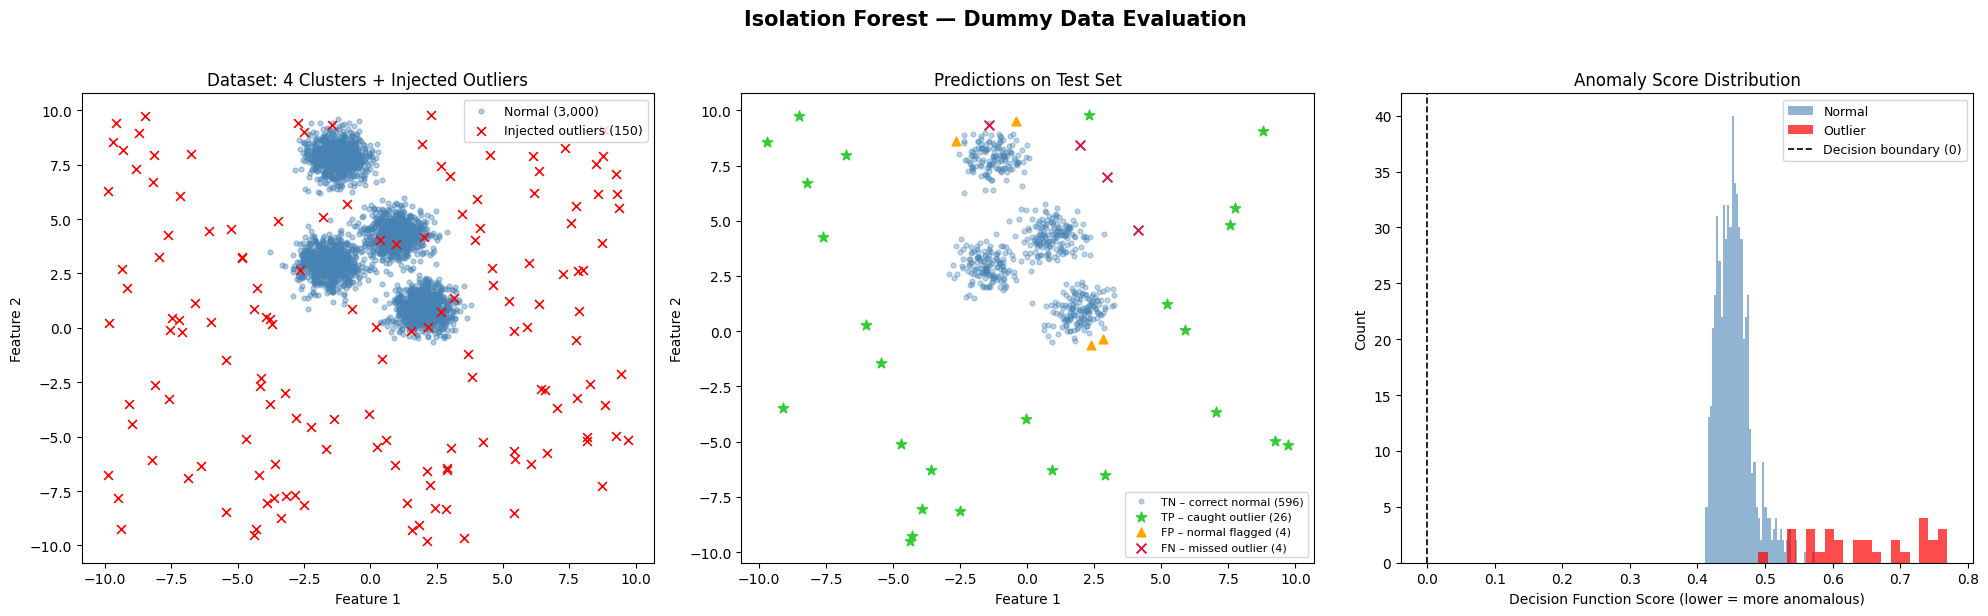


Summary  |  Accuracy: 0.9873   F1: 0.8667
TP=26  FP=4  TN=596  FN=4


In [24]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Isolation Forest — Dummy Data Evaluation", fontsize=15, fontweight="bold", y=1.02)

# ── PLOT 1 : Raw dataset (normal blobs + injected outliers) ──────────────────
ax = axes[0]
ax.scatter(X_normal[:, 0], X_normal[:, 1], s=12, c="steelblue", alpha=0.4, label=f"Normal ({len(X_normal):,})")
ax.scatter(X_outliers[:, 0], X_outliers[:, 1], s=40, c="red", marker="x", linewidths=1.2, label=f"Injected outliers ({len(X_outliers)})")
ax.set_title("Dataset: 4 Clusters + Injected Outliers", fontsize=12)
ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
ax.legend(fontsize=9)

# ── PLOT 2 : Model predictions on test set ───────────────────────────────────
ax = axes[1]
y_scratch_arr = np.array(y_scratch_pred)
y_te_arr      = np.array(y_te)

TP_mask = (y_te_arr == 1) & (y_scratch_arr == 1)
FP_mask = (y_te_arr == 0) & (y_scratch_arr == 1)
TN_mask = (y_te_arr == 0) & (y_scratch_arr == 0)
FN_mask = (y_te_arr == 1) & (y_scratch_arr == 0)

ax.scatter(X_te[TN_mask, 0], X_te[TN_mask, 1], s=12, c="steelblue", alpha=0.35, label=f"TN – correct normal ({TN_mask.sum()})")
ax.scatter(X_te[TP_mask, 0], X_te[TP_mask, 1], s=60, c="limegreen", marker="*", zorder=4, label=f"TP – caught outlier ({TP_mask.sum()})")
ax.scatter(X_te[FP_mask, 0], X_te[FP_mask, 1], s=40, c="orange",   marker="^", zorder=4, label=f"FP – normal flagged ({FP_mask.sum()})")
ax.scatter(X_te[FN_mask, 0], X_te[FN_mask, 1], s=50, c="crimson",  marker="x", linewidths=1.4, zorder=4, label=f"FN – missed outlier ({FN_mask.sum()})")
ax.set_title("Predictions on Test Set", fontsize=12)
ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
ax.legend(fontsize=8)

# ── PLOT 3 : Anomaly score distribution ─────────────────────────────────────
ax = axes[2]
scores = np.array(scratch_model.decision_function(X_te))   # lower = more anomalous
ax.hist(scores[y_te_arr == 0], bins=50, color="steelblue", alpha=0.6, label="Normal")
ax.hist(scores[y_te_arr == 1], bins=20, color="red",       alpha=0.7, label="Outlier")
ax.axvline(0, color="black", linestyle="--", linewidth=1.2, label="Decision boundary (0)")
ax.set_title("Anomaly Score Distribution", fontsize=12)
ax.set_xlabel("Decision Function Score (lower = more anomalous)")
ax.set_ylabel("Count")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nSummary  |  Accuracy: {acc:.4f}   F1: {scratch_f1:.4f}")
print(f"TP={TP_mask.sum()}  FP={FP_mask.sum()}  TN={TN_mask.sum()}  FN={FN_mask.sum()}")
